In [1]:
!git clone https://github.com/elifizg/deep-learning-robustness-and-adversarial-cifar10.git
%cd deep-learning-robustness-and-adversarial-cifar10

Cloning into 'deep-learning-robustness-and-adversarial-cifar10'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 50 (delta 9), reused 14 (delta 5), pack-reused 32 (from 2)
Receiving objects: 100% (50/50), 120.08 MiB | 15.26 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/deep-learning-robustness-and-adversarial-cifar10


In [2]:
# 3. GPU check
import torch
print(torch.cuda.is_available())  # True

True


In [ ]:
# download and save the dataset to Drive
!wget -O /content/drive/MyDrive/Deep_Learning_HW2/CIFAR-10-C.tar https://zenodo.org/record/2535967/files/CIFAR-10-C.tar

--2026-04-04 17:47:55--  https://zenodo.org/record/2535967/files/CIFAR-10-C.tar
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.184.98.114, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/2535967/files/CIFAR-10-C.tar [following]
--2026-04-04 17:47:55--  https://zenodo.org/records/2535967/files/CIFAR-10-C.tar
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 2918471680 (2.7G) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/Deep_Learning_HW2/CIFAR-10-C.tar’

/content/drive/MyDr 100%[===================>]   2.72G  26.5MB/s    in 1m 46s  

2026-04-04 17:49:41 (26.4 MB/s) - ‘/content/drive/MyDrive/Deep_Learning_HW2/CIFAR-10-C.tar’ saved [2918471680/2918471680]



In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Reload the dataset
!tar -xf /content/drive/MyDrive/Deep_Learning_HW2/CIFAR-10-C.tar -C /content/

In [5]:
!git pull

Already up to date.


In [ ]:
# 1. CIFAR-10-C robustness
!python main.py --mode cifar10c \
    --teacher_path best_resnet18_option2.pth \
    --cifar10c_dir /content/CIFAR-10-C


  Mode : cifar10c  |  Device : cuda

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 219MB/s]
  Detected: torchvision ResNet-18 (transfer learning option 2)
  Loaded: best_resnet18_option2.pth
100% 170M/170M [00:04<00:00, 35.1MB/s]
  Dataset split  —  train: 45,000  |  val: 5,000  |  test: 10,000

  Clean test accuracy : 0.9264
  CIFAR-10-C dir      : /content/CIFAR-10-C


──────────────────────────────────────────────────────────────────
  Corruption               Sev1   Sev2   Sev3   Sev4   Sev5    Mean
──────────────────────────────────────────────────────────────────
  brightness              0.924  0.921  0.914  0.903  0.876   0.908
  contrast                0.921  0.863  0.796  0.656  0.270   0.702
  defocus_blur            0.926  0.905  0.850  0.737  0.519   0.787
  elastic_transform       0.869  0.871  0.823  0.767  0.735   0.813
  fog                     0.925  

In [ ]:
# 2. AugMix fine-tuning
!python main.py --mode augmix \
    --teacher_path best_resnet18_option2.pth \
    --save_path best_augmix.pth \
    --cifar10c_dir /content/CIFAR-10-C \
    --epochs 20 --lr 1e-4


  Mode : augmix  |  Device : cuda

  Starting from checkpoint: best_resnet18_option2.pth

  AugMix Fine-tuning
  Epochs     : 20
  LR         : 0.0001
  Severity   : 3
  Width      : 3
  Lambda JSD : 12.0

Epoch 1/20 | loss: 0.7422  ce: 0.1649  jsd: 0.0481 | train acc: 0.9478  val acc: 0.9132
  [saved] val_acc=0.9132 -> best_augmix.pth
Epoch 2/20 | loss: 0.5427  ce: 0.1889  jsd: 0.0295 | train acc: 0.9454  val acc: 0.9169
  [saved] val_acc=0.9169 -> best_augmix.pth
Epoch 3/20 | loss: 0.5020  ce: 0.1874  jsd: 0.0262 | train acc: 0.9470  val acc: 0.9176
  [saved] val_acc=0.9176 -> best_augmix.pth
Epoch 4/20 | loss: 0.4787  ce: 0.1853  jsd: 0.0244 | train acc: 0.9471  val acc: 0.9200
  [saved] val_acc=0.9200 -> best_augmix.pth
Epoch 5/20 | loss: 0.4567  ce: 0.1810  jsd: 0.0230 | train acc: 0.9481  val acc: 0.9167
Epoch 6/20 | loss: 0.3946  ce: 0.1405  jsd: 0.0212 | train acc: 0.9630  val acc: 0.9280
  [saved] val_acc=0.9280 -> best_augmix.pth
Epoch 7/20 | loss: 0.3818  ce: 0.1293  jsd: 0

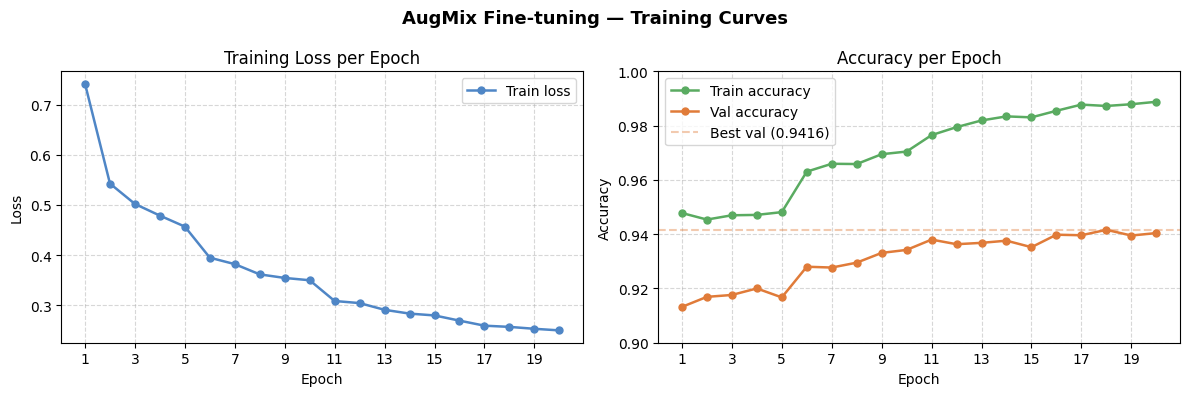

In [ ]:
import json
import matplotlib.pyplot as plt

with open("best_augmix_history.json") as f:
    h = json.load(f)

epochs = range(1, len(h["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: training loss
axes[0].plot(epochs, h["train_loss"], marker="o", color="#4f86c6",
             linewidth=1.8, markersize=5, label="Train loss")
axes[0].set_title("Training Loss per Epoch", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_xticks(range(1, len(h["train_loss"]) + 1, 2))
axes[0].grid(linestyle="--", alpha=0.5)
axes[0].legend()

# Right: train acc vs val acc
axes[1].plot(epochs, h["train_acc"], marker="o", color="#5aab61",
             linewidth=1.8, markersize=5, label="Train accuracy")
axes[1].plot(epochs, h["val_acc"],   marker="o", color="#e07b39",
             linewidth=1.8, markersize=5, label="Val accuracy")
axes[1].axhline(y=max(h["val_acc"]), color="#e07b39", linestyle="--",
                alpha=0.4, label=f"Best val ({max(h['val_acc']):.4f})")
axes[1].set_title("Accuracy per Epoch", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_xticks(range(1, len(h["train_loss"]) + 1, 2))
axes[1].set_ylim(0.90, 1.00)
axes[1].grid(linestyle="--", alpha=0.5)
axes[1].legend()

plt.suptitle("AugMix Fine-tuning — Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("augmix_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# 4. augmix_kd — train again with B.4 standard KD
!python main.py --mode augmix_kd \
    --epochs 20 \
    --teacher_path best_resnet.pth \
    --augmix_path best_augmix.pth


  Mode : augmix_kd  |  Device : cuda


  HW2 Part 4 — KD Comparison: Baseline Teacher vs AugMix Teacher

─────────────────────────────────────────────────────────────────
  B.3  — SimpleCNN  + Baseline teacher
─────────────────────────────────────────────────────────────────
  Dataset : cifar10 | Model : SimpleCNN | KD T=4.0 alpha=0.3 | Device : cuda
100% 170M/170M [00:15<00:00, 11.2MB/s]
  Dataset split  —  train: 45,000  |  val: 5,000  |  test: 10,000
  Loss: KnowledgeDistillation  (T=4.0, alpha=0.3)

Epoch 1/20  (lr=1.00e-03)
    [ 100/704]  loss: 7.4332  acc: 0.2891
    [ 200/704]  loss: 6.7747  acc: 0.3397
    [ 300/704]  loss: 6.3825  acc: 0.3756
    [ 400/704]  loss: 6.1110  acc: 0.3980
    [ 500/704]  loss: 5.9002  acc: 0.4177
    [ 600/704]  loss: 5.7285  acc: 0.4329
    [ 700/704]  loss: 5.5860  acc: 0.4452
  train  loss=5.5817  acc=0.4457
  val    loss=1.5989  acc=0.5630
  [saved]  val_acc=0.5630  ->  best_cnn_kd.pth

Epoch 2/20  (lr=1.00e-03)
    [ 100/704]  loss: 4.5564  

In [7]:
# 3. Then pgd — transferability with new student checkpoint
!python main.py --mode pgd \
    --teacher_path best_resnet18_option2.pth \
    --augmix_path best_augmix.pth \
    --results_dir ./results \
    --augmix_history best_augmix_history.json \
    --baseline_history history_resnet18_option2.json


  Mode : pgd  |  Device : cuda

  Loading baseline : best_resnet18_option2.pth
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 165MB/s]
  Loading AugMix   : best_augmix.pth

──────────────────────────────────────────────────────────────
  Model        Norm   Epsilon      Clean  Adv (PGD20)
──────────────────────────────────────────────────────────────
  Evaluating Baseline — LINF eps=4/255 ...
  Baseline     LINF   eps=4/255    clean: 0.9230  adv: 0.4564
  Evaluating Baseline — L2 eps=0.25 ...
  Baseline     L2     eps=0.25     clean: 0.9230  adv: 0.7838
  Evaluating AugMix — LINF eps=4/255 ...
  AugMix       LINF   eps=4/255    clean: 0.9387  adv: 0.6240
  Evaluating AugMix — L2 eps=0.25 ...
  AugMix       L2     eps=0.25     clean: 0.9387  adv: 0.8486
──────────────────────────────────────────────────────────────

  PGD results saved to: ./results/pgd_results.json

  G